# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

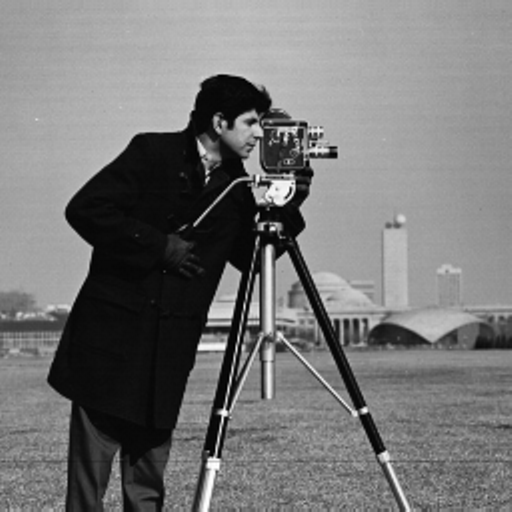

In [3]:
# ── Load image ────────────────────────────────────
image = Image.open("cameraman.jpg").convert("L")
display(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [4]:
# Get the size of the image

# scaling factors

width, height = image.size

cx = 2
cy = 2

print("Original size:", image.size)

Original size: (512, 512)


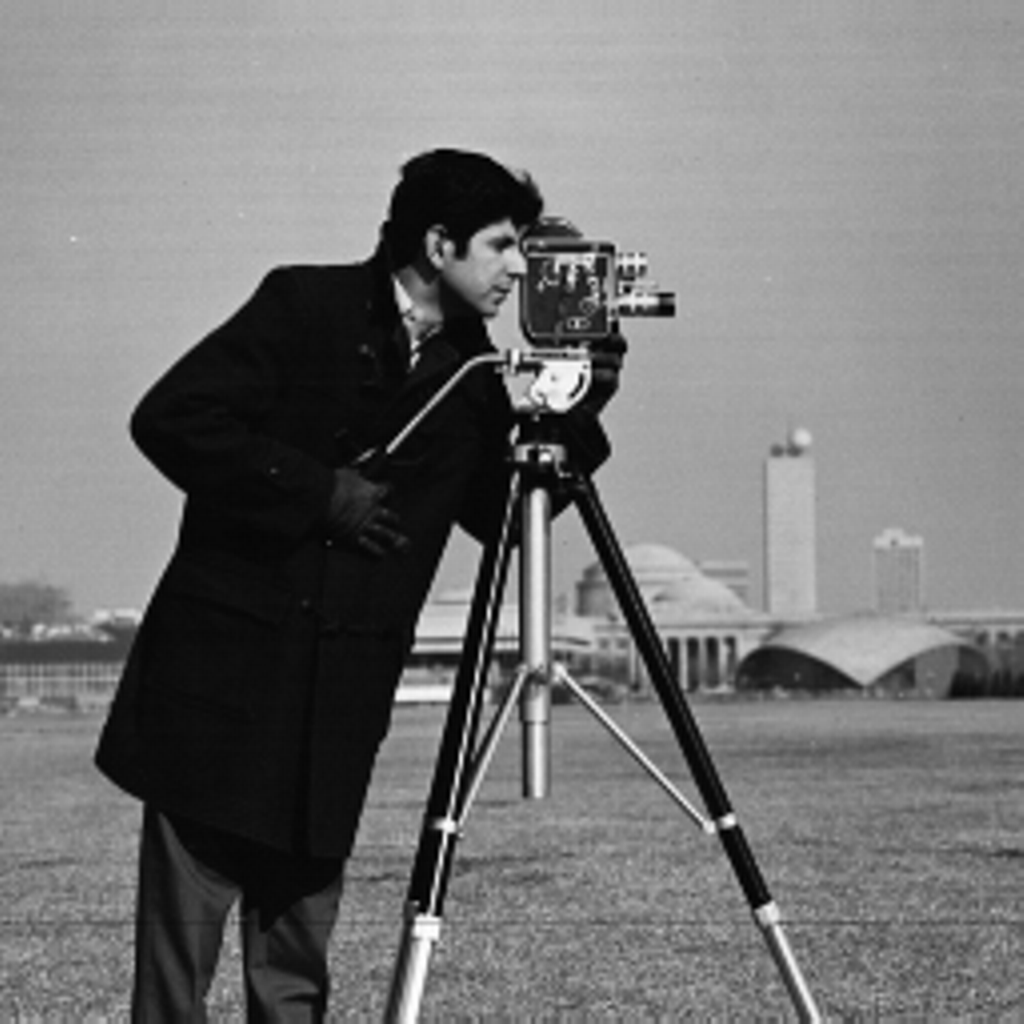

In [5]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

new_width = int(width * cx)
new_height = int(height * cy)

scaled_image = image.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(scaled_image)


In [6]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("Scaled size:", scaled_image.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
cx = 2
cy = 1

width, height = image.size

In [8]:
non_uniform_size = (
    int(width * cx),
    int(height * cy)
)

non_uniform_scaled = image.resize(
    non_uniform_size,
    Image.Resampling.LANCZOS
)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


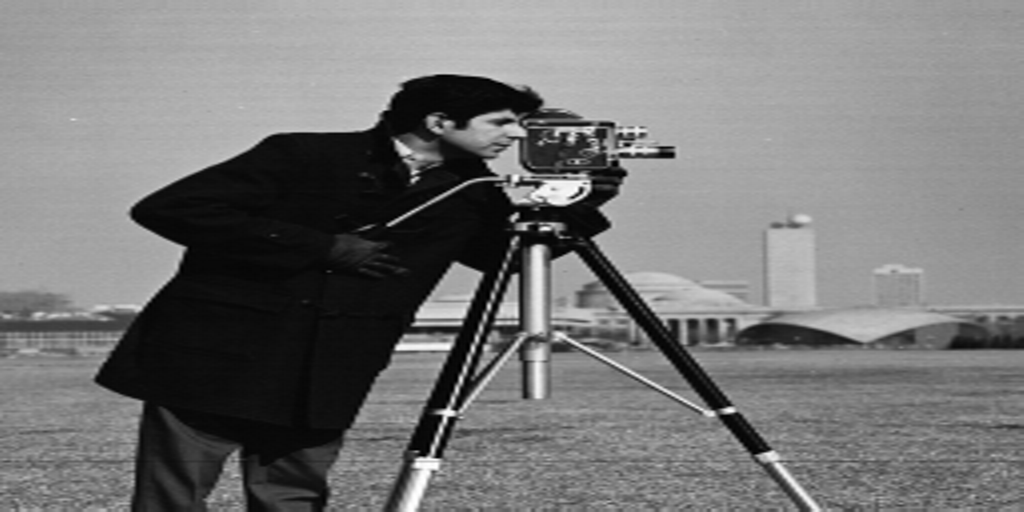

In [9]:
non_uniform_scaled.save(
    "task1_1_non_uniform_scaled.jpg"
)

print("Original size:", image.size)
print("Non-uniform scaled size:", non_uniform_scaled.size)

display(non_uniform_scaled)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


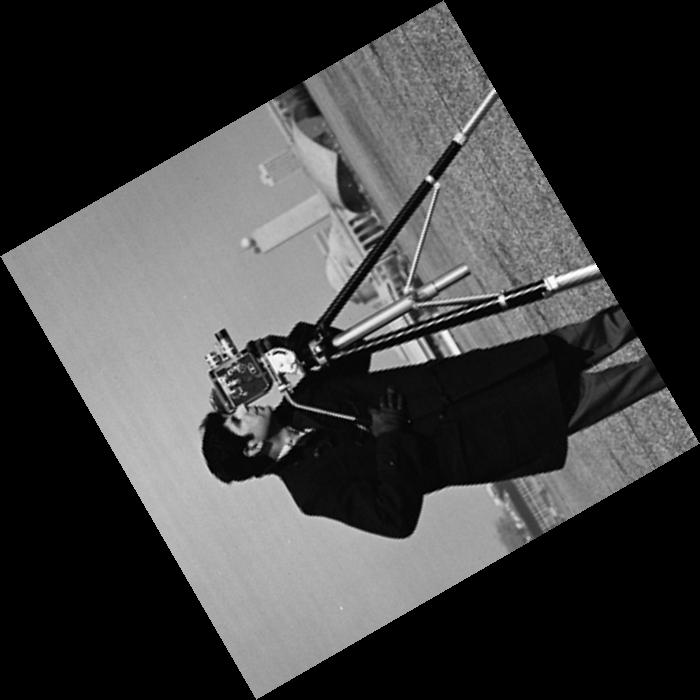

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_image = image.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True,
    fillcolor=0
)

rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

display(rotated_image)

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────

width, height = image.size

print("Original width:", width)
print("Original height:", height)

Original width: 512
Original height: 512


In [12]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5

new_width = int(
    width + abs(shear_factor) * height
)

new_height = height

shear_matrix = (
    1, -shear_factor, 0,
    0, 1, 0
)

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_image = image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

Original size: (512, 512)
Sheared size: (768, 512)


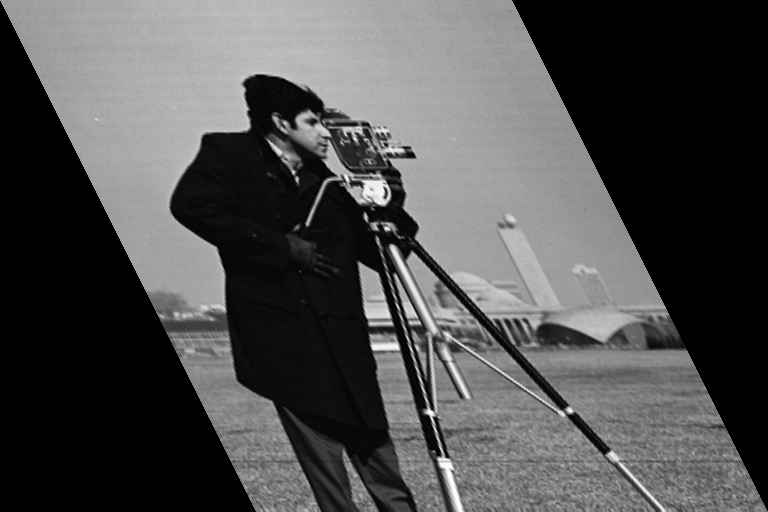

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

print("Original size:", image.size)
print("Sheared size:", sheared_image.size)

display(sheared_image)

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

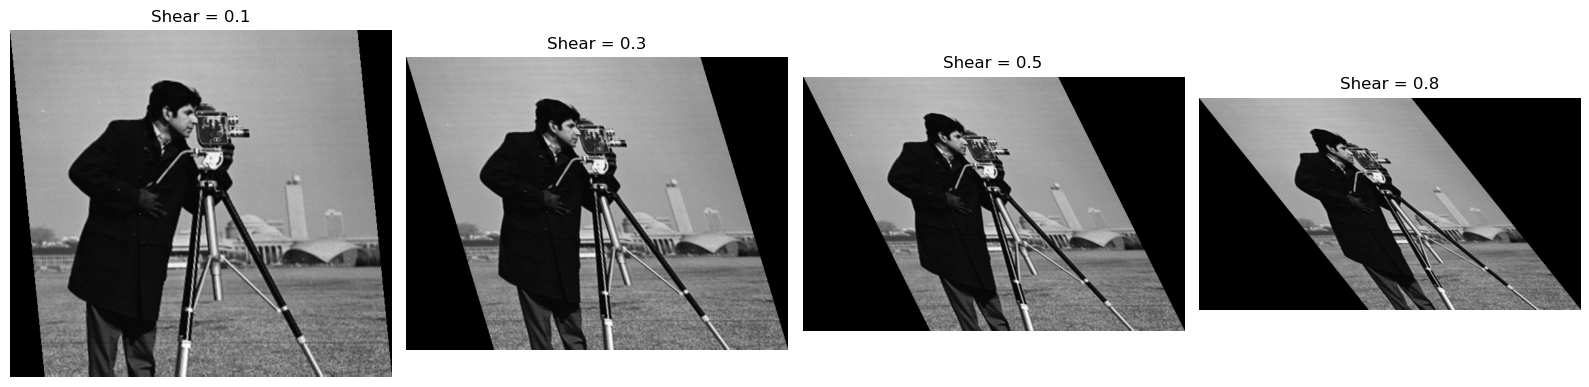

In [15]:
shear_factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(16, 4))

for i, factor in enumerate(shear_factors):
    canvas_width = int(
        width + abs(factor) * height
    )

    matrix = (
        1, -factor, 0,
        0, 1, 0
    )

    result = image.transform(
        (canvas_width, height),
        Image.Transform.AFFINE,
        matrix,
        resample=Image.Resampling.BICUBIC,
        fillcolor=0
    )

    plt.subplot(1, 4, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(f"Shear = {factor}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

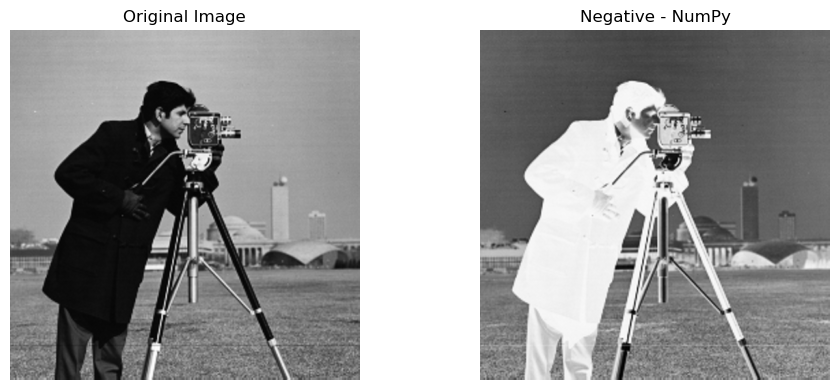

In [21]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

image_array = np.array(image, dtype=np.uint8)

negative_array = 255 - image_array
negative_numpy = Image.fromarray(negative_array)

negative_numpy.save("task2_1_negative_numpy.jpg")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative_numpy, cmap="gray")
plt.title("Negative - NumPy")
plt.axis("off")

plt.tight_layout()
plt.show()


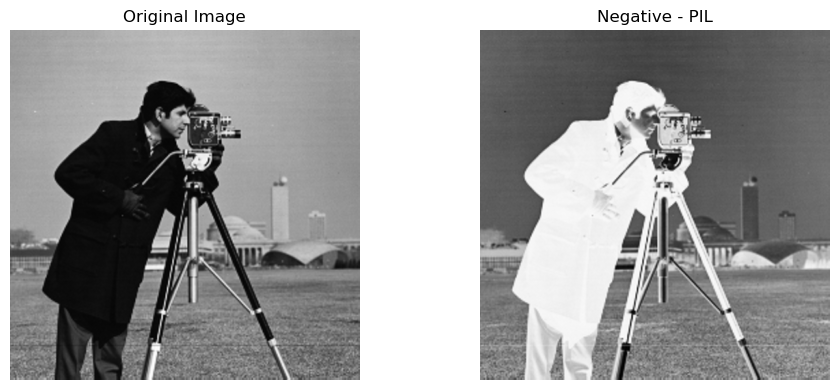

In [17]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)

negative_pil.save("task2_1_negative_pil.jpg")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative_pil, cmap="gray")
plt.title("Negative - PIL")
plt.axis("off")

plt.tight_layout()
plt.show()

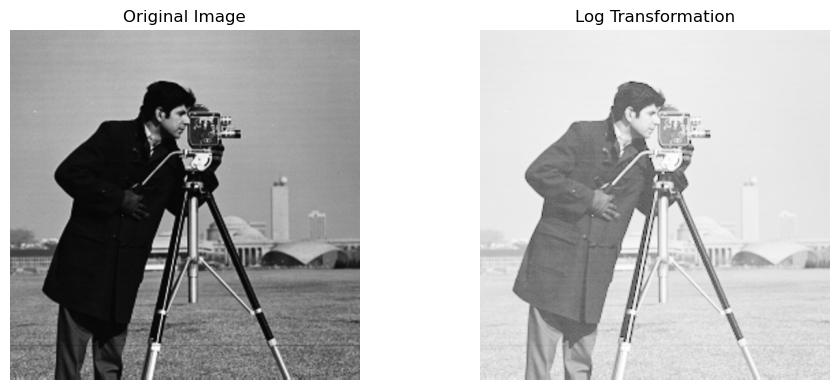

In [18]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
image_array_float = np.array(
    image,
    dtype=np.float32
)

c = 255 / np.log1p(255)

log_transformed_array = (
    c * np.log1p(image_array_float)
)

log_transformed_array = np.clip(
    log_transformed_array,
    0,
    255
).astype(np.uint8)

log_transformed_image = Image.fromarray(
    log_transformed_array
)

log_transformed_image.save(
    "task2_2_log_transformed.jpg"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_transformed_image, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.tight_layout()
plt.show()


# Apply the log transformation to each pixel


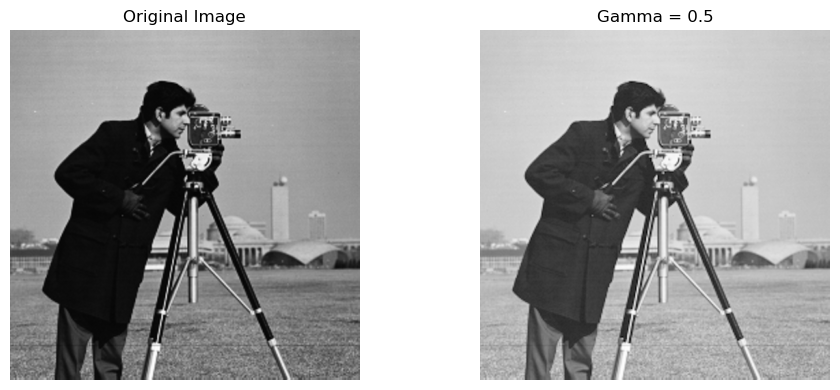

In [19]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

normalized_array = (
    np.array(image, dtype=np.float32) / 255
)

gamma_array = (
    255 * np.power(normalized_array, gamma)
)

gamma_array = np.clip(
    gamma_array,
    0,
    255
).astype(np.uint8)

gamma_image = Image.fromarray(gamma_array)

gamma_image.save("task2_3_gamma.jpg")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gamma_image, cmap="gray")
plt.title(f"Gamma = {gamma}")
plt.axis("off")

plt.tight_layout()
plt.show()

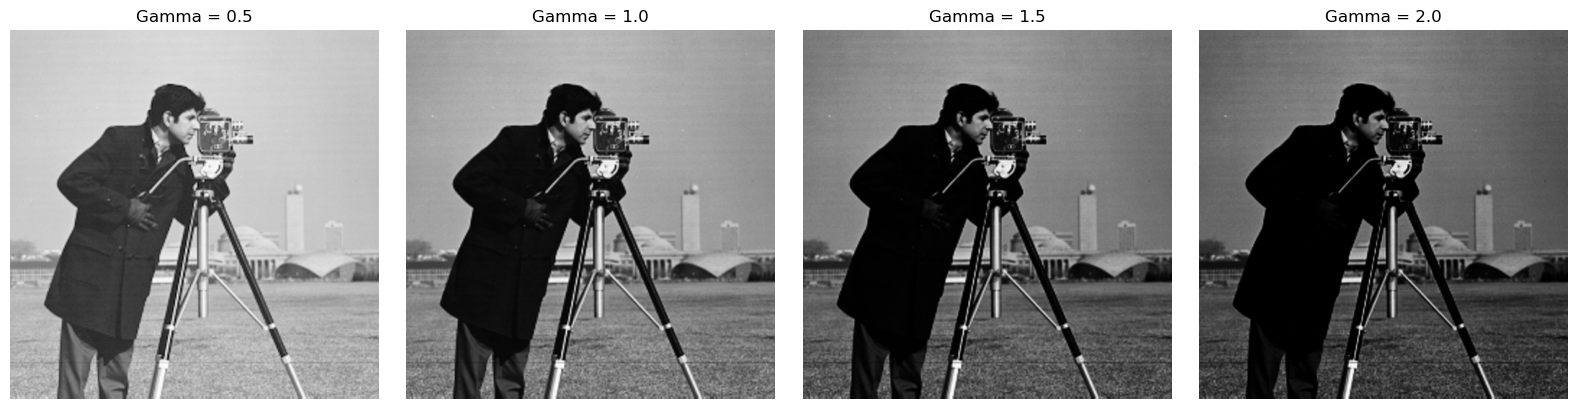

In [20]:
gamma_values = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(16, 4))

for i, gamma in enumerate(gamma_values):
    corrected_array = (
        255 * np.power(normalized_array, gamma)
    )

    corrected_array = np.clip(
        corrected_array,
        0,
        255
    ).astype(np.uint8)

    plt.subplot(1, 4, i + 1)
    plt.imshow(corrected_array, cmap="gray")
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()